# 04 - Forecasting: baselines first, a simple neural network as challenger

Flow: weekly SKU demand -> features -> **time-based** split -> baselines -> linear regression -> MLP (NumPy) -> one optimising metric (WAPE) + satisficing metrics -> bias/variance -> error analysis -> honest verdict.

The full run is `src/07_forecasting.py`; here we walk through the key pieces so you can explain each one.

In [1]:
# --- setup: make the project's src/ folder importable and set paths ---
import sys, json
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, Markdown
import config as cfg
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
N = json.loads((cfg.TABLES / "key_numbers.json").read_text())   # every number the scripts computed
%matplotlib inline

In [2]:
import ast, kpis, features, baselines, metrics, splits, nn_numpy, diagnosis
t = kpis.load_clean()
weekly = kpis.weekly_demand(t)
feat = features.build_feature_table(weekly)
print(splits.validate_split(feat))
display(feat.groupby("split").agg(rows=("y", "size"), first_week=("week_idx", "min"), last_week=("week_idx", "max"), mean_relative_demand=("y_scaled", "mean")).reindex(["train", "dev", "test"]))
display(feat[["sku", "week_idx", "split", "y"] + features.FEATURES].head())

       min  max
split          
dev     72   87
test    88  103
train    8   71


,rows,first_week,last_week,mean_relative_demand
split,,,,
train,5760,8,71,1.006920
dev,1440,72,87,1.075789
test,1440,88,103,1.175304


,sku,week_idx,split,y,lag_1,lag_2,lag_4,roll_mean_4,roll_mean_8,month_sin,month_cos,promo_flag,promo_lag1
0,SKU-00001,8,train,218.0,0.947263,1.011214,1.091151,1.003220,1.012213,0.866025,5.000000e-01,0,0.0
1,SKU-00001,9,train,179.0,0.871322,0.947263,0.963251,0.948262,1.001221,1.000000,6.123234e-17,0,0.0
2,SKU-00001,10,train,227.0,0.715444,0.871322,1.011214,0.886311,0.961252,1.000000,6.123234e-17,0,0.0
3,SKU-00001,11,train,257.0,0.907294,0.715444,0.947263,0.860331,0.930776,1.000000,6.123234e-17,1,0.0
4,SKU-00001,12,train,230.0,1.027201,0.907294,0.871322,0.880315,0.941768,1.000000,6.123234e-17,1,1.0


### Why a time-based split?
A random split would let the model train on weeks AFTER the ones it is tested on. Dev and test are the two latest blocks, so they come from the same recent distribution; test is touched only once at the end.

## 1. Baselines (one-step ahead)
Naive = last week; Moving average = mean of last k weeks; Exponential smoothing = weighted average with decay alpha. k and alpha are tuned on the dev weeks only.

In [3]:
Y, skus = baselines.to_matrix(weekly)
dev_cols = list(range(cfg.TRAIN_WEEKS, cfg.TRAIN_WEEKS + cfg.DEV_WEEKS))
k, alpha = baselines.tune_on_dev(Y, dev_cols)
fc = {"naive": baselines.naive(Y), "ma": baselines.moving_average(Y, k), "ses": baselines.exp_smoothing(Y, alpha), "snaive": baselines.seasonal_naive(Y)}
for name, M in fc.items():
    feat = feat.merge(baselines.to_long(M, skus, name), on=["sku", "week_idx"], how="left")
print("moving-average window:", k, "| smoothing alpha:", alpha)
dev, test = feat[feat.split == "dev"], feat[feat.split == "test"]
display(pd.DataFrame({m: {"dev WAPE": metrics.wape(dev.y, dev[m]), "test WAPE": metrics.wape(test.y, test[m]), "test bias": metrics.bias(test.y, test[m])} for m in fc}).T.round(4))

moving-average window: 4 | smoothing alpha: 0.4


,dev WAPE,test WAPE,test bias
naive,0.1500,0.1277,-0.0030
ma,0.1277,0.1179,-0.0076
ses,0.1275,0.1136,-0.0092
snaive,0.1940,0.1867,-0.0959


## 2. Linear regression, then an MLP
Same 9 features. Inputs are standardised with TRAIN statistics only; targets are scaled by each SKU's train mean so all SKUs live on the same scale.

In [4]:
tr, dv, te = (feat.split == s for s in ("train", "dev", "test"))
sc = features.Standardizer().fit(feat.loc[tr, features.FEATURES])
X = sc.transform(feat[features.FEATURES]); y = feat["y_scaled"].to_numpy(); scale = feat["scale"].to_numpy()
Xb = np.hstack([X, np.ones((len(X), 1))]); coef, *_ = np.linalg.lstsq(Xb[tr.to_numpy()], y[tr.to_numpy()], rcond=None)
feat["linear"] = np.clip(Xb @ coef * scale, 0, None)
display(pd.Series(coef, index=features.FEATURES + ["intercept"]).round(3).to_frame("standardised coefficient"))
print("linear regression: dev WAPE %.4f | test WAPE %.4f" % (metrics.wape(feat.loc[dv, "y"], feat.loc[dv, "linear"]), metrics.wape(feat.loc[te, "y"], feat.loc[te, "linear"])))

,standardised coefficient
lag_1,0.078
lag_2,0.016
lag_4,-0.001
roll_mean_4,0.068
roll_mean_8,0.017
month_sin,-0.017
month_cos,-0.000
promo_flag,0.095
promo_lag1,-0.046
intercept,1.007


linear regression: dev WAPE 0.1098 | test WAPE 0.1022


### Gradient checking (is my back-propagation computing the right gradient?)
Compare analytic gradients with numerical ones. A relative difference below about 1e-6 means correct.

In [5]:
rng = np.random.default_rng(0)
Xs, ys = rng.normal(size=(20, 5)), rng.normal(size=20)
net_check = nn_numpy.NumpyMLP(5, hidden=(4, 3), l2=0.01, seed=1)
net_check.b = [rng.normal(0, .1, size=b.shape) for b in net_check.b]     # non-zero biases (avoid ReLU kink at exactly 0)
print("relative gradient difference:", net_check.gradient_check(Xs, ys))

relative gradient difference: 1.2188907123048658e-10


architecture: [9, 16, 8, 1] | best epoch: 45


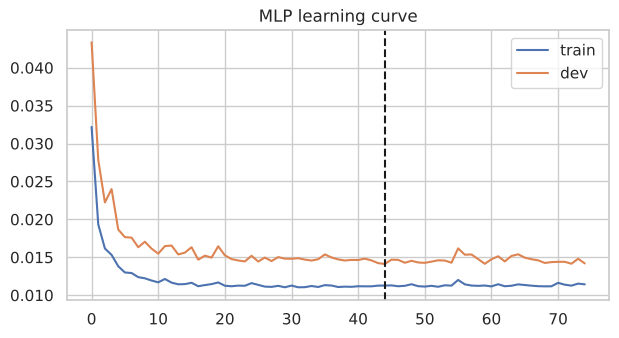

In [6]:
hidden = ast.literal_eval(N["fc_mlp_hidden"]); l2 = N["fc_mlp_l2"]; drop = N["fc_mlp_dropout"]
net = nn_numpy.NumpyMLP(X.shape[1], hidden=hidden, l2=l2, dropout=drop, seed=cfg.NN_SEEDS[0])
net.fit(X[tr.to_numpy()], y[tr.to_numpy()], X[dv.to_numpy()], y[dv.to_numpy()], epochs=300, batch_size=64, lr=0.003, patience=30)
feat["mlp"] = np.clip(net.predict(X) * scale, 0, None)
print("architecture:", net.sizes, "| best epoch:", net.best_epoch)
fig, ax = plt.subplots(figsize=(7, 3.5)); ax.plot(net.history["train_loss"], label="train"); ax.plot(net.history["dev_loss"], label="dev")
ax.axvline(net.best_epoch - 1, color="k", ls="--"); ax.set_title("MLP learning curve"); ax.legend(); plt.show()

## 3. Scorecard: optimising metric (WAPE) + satisficing metrics (RMSE, bias, interpretability)

In [7]:
rows = []
for m in ["naive", "ma", "ses", "snaive", "linear", "mlp"]:
    for s_name, mask in (("train", tr), ("dev", dv), ("test", te)):
        rows.append(dict(model=m, split=s_name, **metrics.score_all(feat.loc[mask, "y"], feat.loc[mask, m])))
score = pd.DataFrame(rows)
display(score.pivot(index="model", columns="split", values="WAPE").round(4))
display(score[score.split == "test"].set_index("model")[["WAPE", "RMSE", "Bias"]].round(4))
display(pd.read_csv(cfg.TABLES / "forecast_model_comparison.csv")[["model", "WAPE_dev", "WAPE_test", "Bias_test", "interpretable", "passes_gates"]])

split,dev,test,train
model,,,
linear,0.1098,0.1022,0.1026
ma,0.1277,0.1179,0.1240
mlp,0.1061,0.1010,0.0995
naive,0.1500,0.1277,0.1344
ses,0.1275,0.1136,0.1210
snaive,0.1940,0.1867,0.1909


,WAPE,RMSE,Bias
model,,,
naive,0.1277,127.3428,-0.0030
ma,0.1179,113.6055,-0.0076
ses,0.1136,111.8623,-0.0092
snaive,0.1867,171.6655,-0.0959
linear,0.1022,100.1611,-0.0193
mlp,0.1010,98.9969,-0.0066


,model,WAPE_dev,WAPE_test,Bias_test,interpretable,passes_gates
0,Naive (last week),0.149978,0.127705,-0.003033,Yes - one line,True
1,Moving average,0.127728,0.117864,-0.007551,Yes - one line,True
2,Exp. smoothing,0.127509,0.113592,-0.009173,Yes - one parameter,True
3,Seasonal naive (ref.),0.193960,0.186736,-0.095878,Yes - one line,False
4,Linear regression,0.109840,0.102230,-0.019305,Yes - 9 coefficients,True
5,MLP (NumPy NN),0.106066,0.100951,-0.006572,Partly - needs permutation importance,True


## 4. Bias vs variance, using the best baseline as the human-level proxy

In [8]:
proxy = N["fc_wape_train_best_baseline"]
for m in ("linear", "mlp"):
    d = diagnosis.diagnose(proxy, score[(score.model == m) & (score.split == "train")].WAPE.iloc[0], score[(score.model == m) & (score.split == "dev")].WAPE.iloc[0])
    print(m, "| avoidable bias %.3f | variance %.3f" % (d["avoidable_bias"], d["variance"])); print("  ->", d["diagnosis"])

linear | avoidable bias -0.018 | variance 0.007
  -> The model already beats the baseline proxy on the training weeks and generalises: bias and variance are both small. Remaining error is likely noise or information these features do not contain.
mlp | avoidable bias -0.021 | variance 0.007
  -> The model already beats the baseline proxy on the training weeks and generalises: bias and variance are both small. Remaining error is likely noise or information these features do not contain.


## 5. Error analysis: the 100 biggest dev errors
Each error is tagged (promo week, post-promo week, outlier week, seasonal turn) and tallied. Open `outputs/tables/error_analysis_top100.csv` in Excel to review rows and fill the `manual_cause` column.

In [9]:
top = pd.read_csv(cfg.TABLES / "error_analysis_top100.csv")
display(pd.read_csv(cfg.TABLES / "error_analysis_tally.csv")); display(top.head(10))
display(top.groupby("category").size().sort_values(ascending=False).to_frame("n_big_errors"))

,primary_cause,n_errors,abs_error_units,under_forecast,share_of_errors,share_of_error_units
0,outlier_week,7,4297.357096,7,0.07,0.158351
1,promo_week,20,5130.465590,4,0.20,0.189050
2,post_promo_week,8,2735.691313,2,0.08,0.100806
3,seasonal_turn,31,7278.009946,14,0.31,0.268183
4,no_clear_cause,34,7696.678618,20,0.34,0.283610


,rank,sku,category,abc_class,week_start,actual,forecast,baseline_forecast,error,abs_error,pct_error,promo_flag,promo_lag1,tag_outlier_week,tag_promo_week,tag_post_promo_week,tag_seasonal_turn,primary_cause,direction,mlp_beats_baseline,manual_cause,notes
0,1,SKU-00088,Raw Materials,A,2025-08-18,8644.0,6272.6,5061.9,-2371.4,2371.4,-0.274,1,1.0,1,1,0,0,outlier_week,under-forecast,1,NaN,NaN
1,2,SKU-00088,Raw Materials,A,2025-08-25,4057.0,5488.1,6494.8,1431.1,1431.1,0.353,0,1.0,0,0,1,0,post_promo_week,over-forecast,1,NaN,NaN
2,3,SKU-00088,Raw Materials,A,2025-07-28,3799.0,4407.8,4516.6,608.8,608.8,0.160,0,0.0,0,0,0,0,no_clear_cause,over-forecast,1,NaN,NaN
3,4,SKU-00020,Raw Materials,A,2025-09-01,1599.0,1106.5,958.2,-492.5,492.5,-0.308,1,1.0,1,1,0,1,outlier_week,under-forecast,1,NaN,NaN
4,5,SKU-00064,Textiles,B,2025-08-25,1092.0,609.2,599.9,-482.8,482.8,-0.442,1,1.0,1,1,0,1,outlier_week,under-forecast,1,NaN,NaN
5,6,SKU-00088,Raw Materials,A,2025-05-26,3989.0,4470.2,4673.5,481.2,481.2,0.121,0,0.0,0,0,0,1,seasonal_turn,over-forecast,1,NaN,NaN
6,7,SKU-00049,Electronics,A,2025-08-11,1988.0,1549.7,1627.7,-438.3,438.3,-0.220,0,0.0,0,0,0,0,no_clear_cause,under-forecast,0,NaN,NaN
7,8,SKU-00049,Electronics,A,2025-06-02,1669.0,1242.2,1243.5,-426.8,426.8,-0.256,0,0.0,0,0,0,1,seasonal_turn,under-forecast,0,NaN,NaN
8,9,SKU-00037,Raw Materials,A,2025-06-30,760.0,1173.3,871.6,413.3,413.3,0.544,1,0.0,0,1,0,0,promo_week,over-forecast,0,NaN,NaN
9,10,SKU-00053,Textiles,A,2025-08-04,2512.0,2112.4,2059.3,-399.6,399.6,-0.159,0,0.0,0,0,0,1,seasonal_turn,under-forecast,1,NaN,NaN


,n_big_errors
category,
Raw Materials,37
Electronics,28
Textiles,19
Machinery Parts,14
Chemicals,2


In [10]:
bk = {"Naive (last week)": "naive", "Moving average": "ma", "Exp. smoothing": "ses"}[N["fc_best_baseline"]]
display(Markdown(f"""### Honest conclusion (numbers from the full run)
* Best baseline on dev: **{N['fc_best_baseline']}**. Test WAPE: baseline **{N['fc_wape_test_' + bk]:.1%}**, linear regression **{N['fc_wape_test_linear']:.1%}**, MLP **{N['fc_wape_test_mlp']:.1%}** (seed range {N['fc_mlp_test_wape_min']:.1%} - {N['fc_mlp_test_wape_max']:.1%}).
* MLP vs baseline: **{N['fc_mlp_rel_gain_vs_baseline_test']:.1%}** relative gain; MLP vs linear: **{N['fc_mlp_rel_gain_vs_linear_test']:.1%}** (we required {cfg.MIN_RELATIVE_GAIN:.0%} to justify extra complexity). Verdict code: `{N['fc_verdict']}`.
* **Final model: {N['fc_final_model']}.** Largest error bucket: *{N['ea_top_cause'].replace('_', ' ')}* ({N['ea_top_cause_share']:.0%} of the top {N['ea_top_n']}).
* **Action:** run **{N['fc_final_model']}** weekly with the promo flag and recent demand, keep **{N['fc_best_baseline']}** as the fallback, and re-test the MLP quarterly as a challenger."""))

### Honest conclusion (numbers from the full run)
* Best baseline on dev: **Exp. smoothing**. Test WAPE: baseline **11.4%**, linear regression **10.2%**, MLP **10.1%** (seed range 10.1% - 10.6%).
* MLP vs baseline: **11.1%** relative gain; MLP vs linear: **1.3%** (we required 5% to justify extra complexity). Verdict code: `NN_WINS`.
* **Final model: Linear regression.** Largest error bucket: *no clear cause* (34% of the top 100).
* **Action:** run **Linear regression** weekly with the promo flag and recent demand, keep **Exp. smoothing** as the fallback, and re-test the MLP quarterly as a challenger.